# Why one train/test split lies

Lesson 1 gave you the rule: hold data out, never look at it, report the score
you get on it. Lessons 3 and 4 used that rule and it worked.

This notebook shows what the rule does *not* give you — and it is the thing
almost everyone assumes it gives.

**A test score is a measurement, and measurements have error bars.** The number
you get depends on which rows happened to land in the test set, and on a
realistic dataset that dependence is much larger than people expect. Large
enough that a single split can declare the wrong model the winner, and large
enough that it can hand you a perfect score for a model that is not perfect.

We use the disk fleet from lesson 4, cut down to **800 drives**. That is not to
make a point easier to prove — it is because 800 records with 29 positives is a
far more common situation than 8,000, and the instability we are about to see is
what the honest version of that situation looks like.

In [1]:
# pip install numpy==1.26.4 pandas==2.1.1 matplotlib==3.8.0 scikit-learn==1.3.1

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import (KFold, StratifiedKFold, cross_val_score,
                                     train_test_split)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

from methodology_data import load_fleet

FIGURES = Path.cwd().parent / "Figures"
FIGURES.mkdir(exist_ok=True)

BLUE, TEAL, RUST, GOLD = "#1F4E79", "#2E7D8A", "#9C4221", "#F0BE50"
INK, SLATE = "#1A1A1A", "#4A5568"
plt.rcParams.update({
    "font.size": 11, "axes.edgecolor": SLATE, "axes.labelcolor": INK,
    "text.color": INK, "xtick.color": SLATE, "ytick.color": SLATE,
})


def fresh_model(C=1.0):
    return make_pipeline(StandardScaler(),
                         LogisticRegression(max_iter=2_000, C=C))


X, y = load_fleet(800)
print(f"{len(X)} drives, {int(y.sum())} failures ({y.mean():.1%})")

800 drives, 29 failures (3.6%)


## 1. Two honest experiments, two different answers

Here is the whole problem in eight lines. We split the data, fit the model,
score it on the held-out quarter. Everything is done correctly — nothing is
fitted before the split, the test set is never inspected.

Then we do it again, changing one thing: the random seed.

In [2]:
for seed in (0, 1, 2, 3, 4):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=seed, stratify=y)
    model = fresh_model().fit(X_train, y_train)
    auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
    print(f"random_state={seed}:  test AUC = {auc:.3f}"
          f"   ({int(y_test.sum())} failures in the test set)")

random_state=0:  test AUC = 0.961   (7 failures in the test set)
random_state=1:  test AUC = 0.966   (7 failures in the test set)
random_state=2:  test AUC = 0.980   (7 failures in the test set)
random_state=3:  test AUC = 1.000   (7 failures in the test set)
random_state=4:  test AUC = 0.990   (7 failures in the test set)


Same data. Same model. Same code. **The only thing that changed is which rows
happened to be held out.**

Look at `random_state=3`. **AUC 1.000** — a perfect classifier, every failing
drive ranked above every healthy one. Nothing was done wrong to obtain it: the
split is legitimate, the model never saw the test rows, the metric is computed
correctly. It is simply a lie, and by the end of this notebook we will know that
this model's honest performance is about 0.95.

If you had run this once and written down whichever number came out, you would
have reported it as *the* performance of the model. It is not. It is one draw
from a distribution, and we have no idea yet how wide that distribution is.

Note also the last column: each test set contains **7 failures**. Every AUC
above is computed from seven positive examples. That is what 800 rows with a
3.6% positive rate actually buys you, and it is why the numbers move so much.

## 2. How wide is it?

The honest way to find out is to stop guessing and draw two hundred of them.

In [3]:
def split_score(seed, C=1.0):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=seed, stratify=y)
    model = fresh_model(C).fit(X_train, y_train)
    return roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])


scores = np.array([split_score(seed) for seed in range(200)])

print(f"200 splits of the same data, the same model:")
print(f"  worst   {scores.min():.3f}")
print(f"  best    {scores.max():.3f}")
print(f"  spread  {scores.max() - scores.min():.3f}")
print(f"  mean    {scores.mean():.3f}  (standard deviation {scores.std():.3f})")
print(f"\nhow often the score lands above 0.99: "
      f"{(scores > 0.99).sum()} times in 200")

200 splits of the same data, the same model:
  worst   0.885
  best    1.000
  spread  0.115
  mean    0.955  (standard deviation 0.024)

how often the score lands above 0.99: 10 times in 200


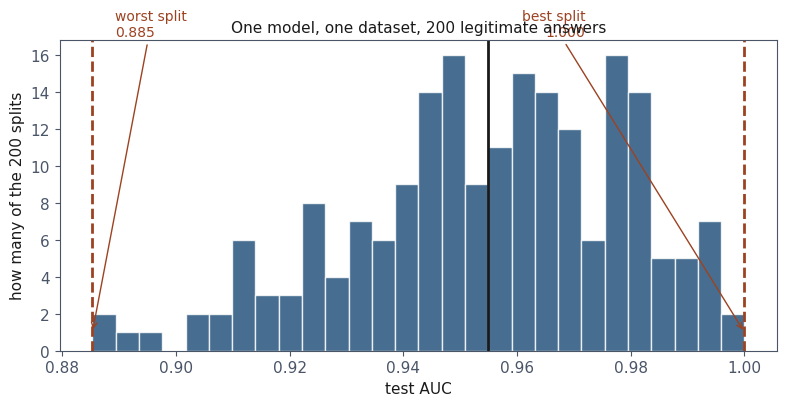

In [4]:
fig, ax = plt.subplots(figsize=(8.0, 4.2))
ax.hist(scores, bins=28, color=BLUE, alpha=.82, edgecolor="white")
ax.axvline(scores.mean(), color=INK, lw=2)
ax.axvline(scores.min(), color=RUST, lw=2, ls="--")
ax.axvline(scores.max(), color=RUST, lw=2, ls="--")
ax.annotate(f"worst split\n{scores.min():.3f}", xy=(scores.min(), 1),
            xytext=(scores.min() + 0.004, 17), color=RUST, fontsize=10,
            arrowprops=dict(arrowstyle="->", color=RUST))
ax.annotate(f"best split\n{scores.max():.3f}", xy=(scores.max(), 1),
            xytext=(scores.max() - 0.028, 17), color=RUST, fontsize=10,
            ha="right", arrowprops=dict(arrowstyle="->", color=RUST))
ax.set_xlabel("test AUC")
ax.set_ylabel("how many of the 200 splits")
ax.set_title("One model, one dataset, 200 legitimate answers", fontsize=11)
fig.tight_layout()
fig.savefig(FIGURES / "split_lottery.png", dpi=150, bbox_inches="tight",
            facecolor="white")
plt.show()

**The right-hand tail is the dangerous end, not the left.**

A bad split gives you a disappointing number, you frown, and you keep working.
A good split gives you a number you are delighted with — and you stop, write it
down, and put it in a report. The splits that flatter you are the ones you are
least likely to question.

Notice how many of the 200 splits scored above 0.99. Each of those is a
perfectly legitimate experiment, correctly performed, that reports a nearly
perfect classifier. **None of them is a lie and none of them is the truth.**

## 3. Now the part that actually costs you: choosing a model

Reporting a noisy number is bad. *Choosing* with a noisy number is worse,
because the noise does not average out — it decides.

Here are three logistic regressions differing only in the strength of their
penalty. Their honest performance is nearly identical, as we are about to
confirm. Let a single split pick the winner, two hundred times.

In [5]:
CANDIDATES = {"C = 0.01": 0.01, "C = 1": 1.0, "C = 100": 100.0}

wins = {name: 0 for name in CANDIDATES}
per_model = {name: [] for name in CANDIDATES}

for seed in range(200):
    best_name, best_score = None, -np.inf
    for name, C in CANDIDATES.items():
        score = split_score(seed, C)
        per_model[name].append(score)
        if score > best_score:
            best_name, best_score = name, score
    wins[best_name] += 1

summary = pd.DataFrame({
    "mean AUC": {n: np.mean(v) for n, v in per_model.items()},
    "std": {n: np.std(v) for n, v in per_model.items()},
    "times declared best": wins,
})
print(summary.to_string(float_format=lambda v: f"{v:.4f}"))

          mean AUC    std  times declared best
C = 0.01    0.9549 0.0240                   91
C = 1       0.9549 0.0240                   71
C = 100     0.9544 0.0243                   38


Read the first column, then the third.

**The three models are the same.** Their mean AUC agrees to three decimal
places — a difference far smaller than the spread we measured in section 2.
Whatever the penalty is doing here, it is not changing how well the model
separates failing drives from healthy ones.

**And yet a single split declares a winner every time.** The counts in the third
column are not evidence about the models. They are a record of which model
happened to suit which random quarter of the data.

Run this experiment once — which is what you do in real life — and you will
report that one of these three is best, with a number to support it. **That
conclusion is noise wearing the clothes of a result.**

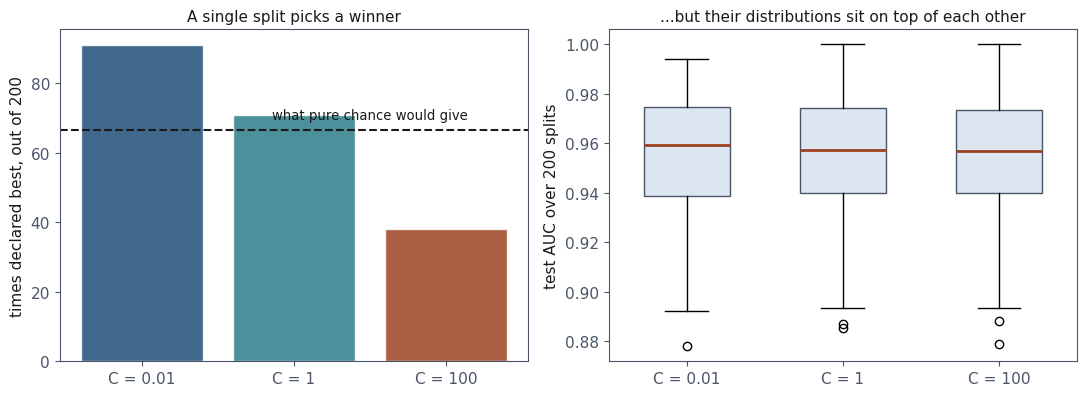

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.1))

axes[0].bar(list(wins), list(wins.values()),
            color=[BLUE, TEAL, RUST], alpha=.85, edgecolor="white")
axes[0].axhline(200 / 3, color=INK, ls="--", lw=1.5)
axes[0].text(1.5, 200 / 3 + 3, "what pure chance would give", ha="center",
             fontsize=9.5, color=INK)
axes[0].set_ylabel("times declared best, out of 200")
axes[0].set_title("A single split picks a winner", fontsize=11)

axes[1].boxplot([per_model[n] for n in CANDIDATES], labels=list(CANDIDATES),
                widths=.55, patch_artist=True,
                boxprops=dict(facecolor="#DCE6F0", edgecolor=SLATE),
                medianprops=dict(color=RUST, lw=2))
axes[1].set_ylabel("test AUC over 200 splits")
axes[1].set_title("...but their distributions sit on top of each other",
                  fontsize=11)

fig.tight_layout()
fig.savefig(FIGURES / "single_split_selection.png", dpi=150,
            bbox_inches="tight", facecolor="white")
plt.show()

## 4. k-fold cross-validation

The fix is not a cleverer split. It is to stop relying on one.

**The idea in a sentence.** Cut the data into $k$ equal parts. Train on $k-1$ of
them and test on the one left out; repeat until every part has served as the
test set exactly once. You get $k$ scores, and every row has been predicted
exactly once by a model that never saw it.

That last clause is what makes it legitimate. It is not "testing on the training
data with extra steps" — each prediction still comes from a model trained
without that row.

Let us build it by hand before calling the library, because the mechanism is
four lines and worth owning.

In [7]:
def cross_validate_by_hand(X, y, k=5, C=1.0, seed=0):
    """Return one score per fold. Stratified, so folds keep the class balance."""
    folds = StratifiedKFold(n_splits=k, shuffle=True, random_state=seed)
    scores = []
    for train_index, test_index in folds.split(X, y):
        model = fresh_model(C).fit(X.iloc[train_index], y.iloc[train_index])
        probability = model.predict_proba(X.iloc[test_index])[:, 1]
        scores.append(roc_auc_score(y.iloc[test_index], probability))
    return np.array(scores)


by_hand = cross_validate_by_hand(X, y, k=5)
from_sklearn = cross_val_score(
    fresh_model(), X, y, scoring="roc_auc",
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=0))

print("fold scores, by hand    :", np.round(by_hand, 4))
print("fold scores, scikit-learn:", np.round(from_sklearn, 4))
print(f"\nagreement: {np.abs(by_hand - from_sklearn).max():.2e}")
print(f"\nestimate: {by_hand.mean():.4f} +/- {by_hand.std():.4f}")

fold scores, by hand    : [0.929  0.9578 0.9838 0.9394 0.947 ]
fold scores, scikit-learn: [0.929  0.9578 0.9838 0.9394 0.947 ]

agreement: 0.00e+00

estimate: 0.9514 +/- 0.0187


**Report the spread, not just the mean.** Those five fold scores are five
measurements of the same quantity, and their spread tells you how much to trust
the average. A cross-validation result quoted as a single number has thrown away
half of what it computed.

The standard error of the mean is the spread divided by the square root of the
number of folds — but treat it as a rough guide rather than a proper confidence
interval, for a reason the handout makes precise: **the folds are not
independent.** Any two training sets share most of their rows, so the five
scores are correlated, and the usual formula understates the true uncertainty.

## 5. Stratification is not optional here

`StratifiedKFold` keeps each fold's class balance equal to the whole dataset's.
With 29 failures among 800 drives, the alternative is not merely untidy — it can
produce a fold with almost no positives in it, and a metric computed on such a
fold is meaningless.

Compare.

In [8]:
plain = KFold(n_splits=5, shuffle=True, random_state=3)
stratified = StratifiedKFold(n_splits=5, shuffle=True, random_state=3)

print(f"{'fold':>6}{'plain KFold':>26}{'StratifiedKFold':>26}")
for index, ((_, plain_test), (_, strat_test)) in enumerate(
        zip(plain.split(X, y), stratified.split(X, y)), 1):
    p, s = y.iloc[plain_test], y.iloc[strat_test]
    print(f"{index:>6}{f'{int(p.sum())} failures of {len(p)}':>26}"
          f"{f'{int(s.sum())} failures of {len(s)}':>26}")

print(f"\nfleet-wide rate: {y.mean():.2%}")

  fold               plain KFold           StratifiedKFold
     1         7 failures of 160         5 failures of 160
     2         1 failures of 160         6 failures of 160
     3         7 failures of 160         6 failures of 160
     4         5 failures of 160         6 failures of 160
     5         9 failures of 160         6 failures of 160

fleet-wide rate: 3.62%


## 6. So how much does cross-validation actually help?

It reduces the variance of the estimate. It does not abolish it — cross-validation
has a random seed too, and shuffling differently gives a different answer.

The honest comparison is: **how much does the number move when I change only the
seed?** For a single split against 5-fold cross-validation.

In [9]:
single = np.array([split_score(seed) for seed in range(40)])
crossval = np.array([cross_validate_by_hand(X, y, k=5, seed=seed).mean()
                     for seed in range(40)])

comparison = pd.DataFrame({
    "single 75/25 split": [single.min(), single.max(),
                           single.max() - single.min(), single.std()],
    "5-fold cross-validation": [crossval.min(), crossval.max(),
                                crossval.max() - crossval.min(), crossval.std()],
}, index=["worst", "best", "spread", "std"])
print(comparison.to_string(float_format=lambda v: f"{v:.4f}"))

print(f"\ncross-validation is "
      f"{single.std() / crossval.std():.1f}x more stable across seeds")

        single 75/25 split  5-fold cross-validation
worst               0.9119                   0.9439
best                1.0000                   0.9588
spread              0.0881                   0.0149
std                 0.0221                   0.0032

cross-validation is 6.8x more stable across seeds


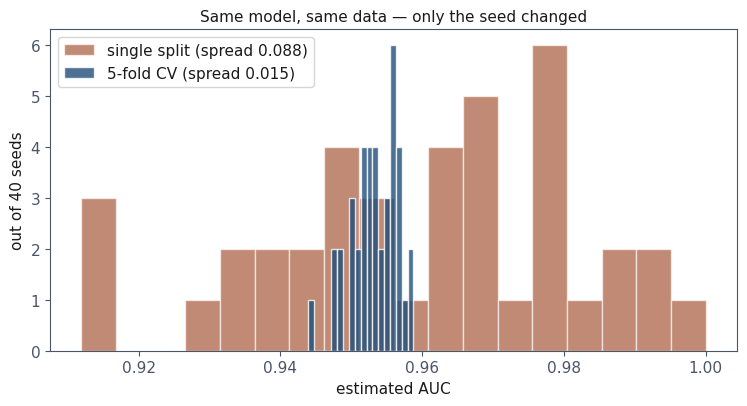

In [10]:
fig, ax = plt.subplots(figsize=(7.6, 4.2))
ax.hist(single, bins=18, color=RUST, alpha=.62, edgecolor="white",
        label=f"single split (spread {single.max() - single.min():.3f})")
ax.hist(crossval, bins=18, color=BLUE, alpha=.80, edgecolor="white",
        label=f"5-fold CV (spread {crossval.max() - crossval.min():.3f})")
ax.set_xlabel("estimated AUC")
ax.set_ylabel("out of 40 seeds")
ax.set_title("Same model, same data — only the seed changed", fontsize=11)
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES / "cv_vs_single_split.png", dpi=150, bbox_inches="tight",
            facecolor="white")
plt.show()

Both distributions sit at roughly the same place — cross-validation is not
*more optimistic*, it is *less arbitrary*. The blue histogram is narrower,
which is exactly the claim: the same amount of data, used more thoroughly, gives
an estimate that depends less on luck.

**What it costs.** Five folds means fitting the model five times. For the models
in this course that is seconds; for a large neural network it is a real
decision, and the usual compromise is a single validation set with enough rows
in it that its own error bar is acceptable.

**What it does not fix**, and this is the part people forget: cross-validation
estimates the performance of a *procedure*, using all the data. It does not
protect you from leakage — if you scaled or imputed before splitting, every fold
is contaminated and the folds agree with each other about a wrong answer.
Notebook 3 is about that.

## What to take away

- **A test score is a measurement with an error bar.** On 800 drives with 29
  failures, the same model scored anywhere from **0.885 to a perfect 1.000**
  depending only on the seed, against an honest value near 0.951.
- **The flattering splits are the dangerous ones.** A disappointing score makes
  you keep working; a perfect one makes you stop and publish.
- **Selecting a model on a single split selects noise.** Three models with
  identical honest performance each won a share of 200 splits.
- **k-fold cross-validation** gives every row a turn as test data, and every
  prediction still comes from a model that never saw that row.
- **Report the spread with the mean.** And remember the folds are correlated,
  so the usual standard error is optimistic.
- **Stratify** when a class is rare, or a fold may contain almost none of it.

Notebook 2 asks the next question: *why* does the error move at all, and what is
it made of?